# Supermarket Sales Analysis
### Data Analytics Project

---

## 1. Problem Statement


Supermarkets handle thousands of transactions daily. Understanding how different products, branches, and customer segments perform is crucial for inventory planning and boosting revenue. In this project, I'm diving into a dataset of 500 supermarket sales transactions to uncover trends in product popularity, branch performance, customer preferences, and payment habits.

## 2. The Dataset

You can check out the raw data via this [Google Sheets link](https://docs.google.com/spreadsheets/d/1QIX__4VObHFMEXnRM2xJyXmB5JAB2peHrJcQ41_U9TE/edit?usp=sharing). 

The dataset tracks 500 sales records covering invoice details, store locations (branches and cities), customer demographics, product categories, unit prices, quantities, payment methods, and customer ratings. 



## 3. Steps Used for Analysis

1. Collect and load the dataset.
2. Check the data for missing or incorrect values.
3. Calculate Sales = Quantity × Unit Price.
4. Group and summarize the data using totals, counts, and averages.
5. Create charts to compare the results.
6. Use the results to make business decisions.

### Step 1: Collect and Load the Dataset

In [3]:
pip install openpyxl


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_excel("SUPER MARKET DATA.xlsx")  
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()

Rows: 500 | Columns: 13


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


### Step 2: Check for Missing or Incorrect Values

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Invoice ID     500 non-null    object        
 1   Date           500 non-null    datetime64[ns]
 2   Branch         500 non-null    object        
 3   City           500 non-null    object        
 4   Customer Type  500 non-null    object        
 5   Gender         500 non-null    object        
 6   Product        500 non-null    object        
 7   Category       500 non-null    object        
 8   Quantity       500 non-null    int64         
 9   Unit Price     500 non-null    float64       
 10  Payment        500 non-null    object        
 11  Rating         500 non-null    float64       
 12  Sales          500 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 50.9+ KB


In [18]:
# Quick validation check
print("--- DATA VALIDATION ---")
print("Missing values:\n", df.isnull().sum())
print("Duplicate invoices:", df['Invoice ID'].duplicated().sum())
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

--- DATA VALIDATION ---
Missing values:
 Invoice ID       0
Date             0
Branch           0
City             0
Customer Type    0
Gender           0
Product          0
Category         0
Quantity         0
Unit Price       0
Payment          0
Rating           0
Sales            0
dtype: int64
Duplicate invoices: 0
Date range: 2026-01-01 to 2026-07-01


In [10]:
df.describe()

,Date,Quantity,Unit Price,Rating,Sales
count,500,500.000000,500.000000,500.000000,500.000000
mean,2026-04-03 12:25:55.199999744,5.536000,88.660700,3.994400,488.822160
min,2026-01-01 00:00:00,1.000000,27.670000,3.000000,28.610000
25%,2026-02-17 00:00:00,3.000000,43.955000,3.500000,189.212500
50%,2026-04-09 00:00:00,5.500000,61.880000,4.000000,335.910000
75%,2026-05-17 06:00:00,8.000000,128.567500,4.500000,609.885000
max,2026-07-01 00:00:00,10.000000,236.710000,5.000000,2114.820000
std,NaN,2.875629,57.284029,0.574481,437.327833


## Quick sanity check: 
No missing values, no duplicate invoice IDs, and data types look solid. We're good to go!

### Step 3: Feature Engineering

Let's add a `Total` column (Unit Price × Quantity) so we can easily track revenue per transaction and analyze branch performance.

### Step 3: Calculate Sales = Quantity × Unit Price

In [19]:
# Recalculate sales, check for mismatches, and show summary stats
df["Sales"] = (df["Quantity"] * df["Unit Price"]).round(2)

print("Mismatched rows:", (abs((df["Quantity"] * df["Unit Price"]) - df["Sales"]) > 0.01).sum())
print(f"Total Sales          : Rs {df['Sales'].sum():,.2f}")
print(f"Average Invoice Value: Rs {df['Sales'].mean():,.2f}")
print(f"Average Rating       : {df['Rating'].mean():.2f} / 5")

Mismatched rows: 0
Total Sales          : Rs 244,411.08
Average Invoice Value: Rs 488.82
Average Rating       : 3.99 / 5


### Step 4 & 5: Group, Summarize and Visualize

The analysis below answers each business question using totals, counts and averages, followed by a chart.

#### Q1. Which product generates the highest sales?

Top Product: Cheese (Rs 27,906.30)

Product
Cheese         27906.30
Coffee         27694.87
Shampoo        27497.48
Cooking Oil    21525.06
Tea            17681.59
Apples         17057.41
Face Wash      11946.85
Rice           11754.17
Cold Drink     10731.78
Eggs           10429.77
Name: Sales, dtype: float64


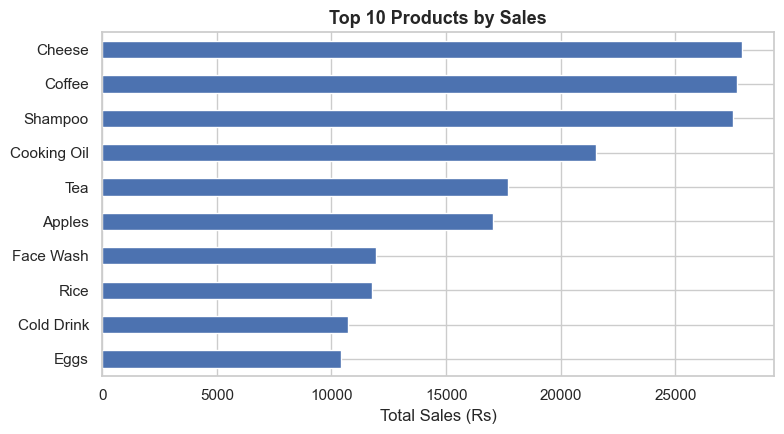

In [20]:
# Group by product and sort top sales
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

# Print top product and top 10 list
print(f"Top Product: {product_sales.index[0]} (Rs {product_sales.iloc[0]:,.2f})\n")
print(product_sales.head(10).round(2))

# Plot top 10 products
product_sales.head(10).sort_values().plot(kind="barh", color="#4C72B0", title="Top 10 Products by Sales")
plt.xlabel("Total Sales (Rs)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Step 4: Branch Performance

Let's look at total sales grouped by each store branch to see which location is performing best.

#### Q2. Which branch performs best?

Top Branch: C (Mumbai) with sales of Rs 72,469.45

Branch      City    Sales
     C    Mumbai 72469.45
     B     Delhi 64116.26
     D Bengaluru 55468.29
     A    Jaipur 52357.08


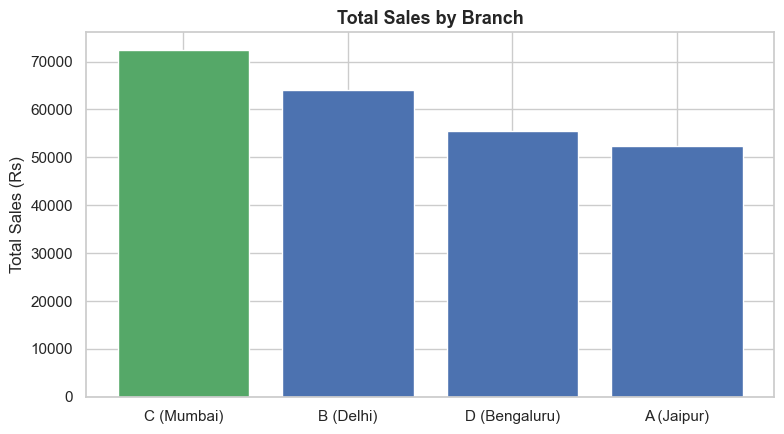

In [21]:
# Group by Branch & City and sort sales
branch_sales = df.groupby(["Branch", "City"])["Sales"].sum().reset_index().sort_values(by="Sales", ascending=False)

# Print best branch and full summary table
best = branch_sales.iloc[0]
print(f"Top Branch: {best['Branch']} ({best['City']}) with sales of Rs {best['Sales']:,.2f}\n")
print(branch_sales.round(2).to_string(index=False))

# Plot total sales by branch
labels = branch_sales["Branch"] + " (" + branch_sales["City"] + ")"
plt.bar(labels, branch_sales["Sales"], color=["#55A868", "#4C72B0", "#4C72B0", "#4C72B0"])
plt.title("Total Sales by Branch")
plt.ylabel("Total Sales (Rs)")
plt.tight_layout()
plt.show()

### Step 5: Product Category Performance

Let's figure out which product lines are generating the highest total sales across all branches.

#### Q3. Which category sells the most?

Top Category: Beverages (Rs 56,108.24)

Category
Beverages        56108.24
Personal Care    45943.96
Dairy            43992.00
Grocery          40470.47
Fruits           23263.17
Snacks           16992.97
Vegetables       11124.17
Bakery            6516.10
Name: Sales, dtype: float64


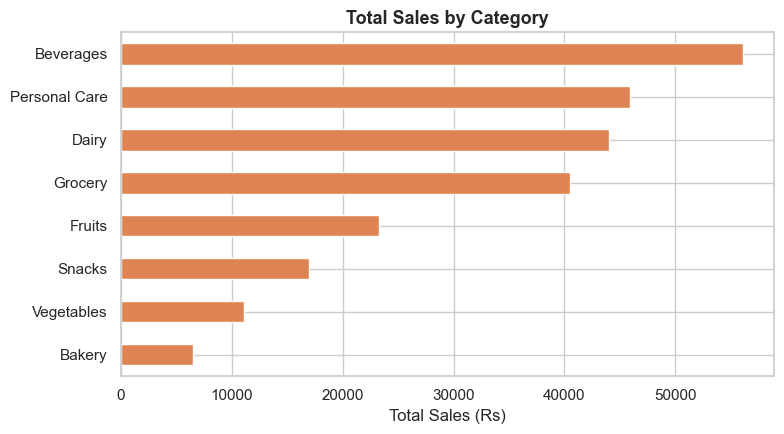

In [22]:
# Group by product category and sort sales
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

# Print top category and full sorted list
print(f"Top Category: {category_sales.index[0]} (Rs {category_sales.iloc[0]:,.2f})\n")
print(category_sales.round(2))

# Plot category sales as a horizontal bar chart
category_sales.sort_values().plot(kind="barh", color="#DD8452", title="Total Sales by Category")
plt.xlabel("Total Sales (Rs)")
plt.ylabel("")
plt.tight_layout()
plt.show()

#### Q4. What is the most popular payment method?

Most Used Payment: UPI (127 transactions)

Payment
UPI            127
Net Banking    126
Card           125
Cash           122
Name: count, dtype: int64


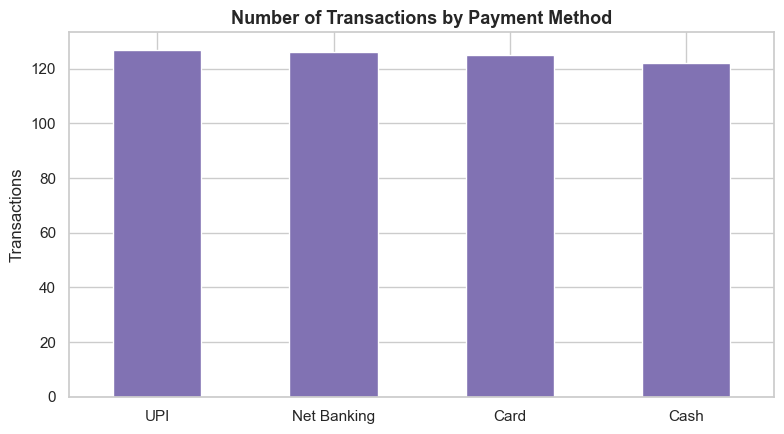

In [23]:
# Count transactions by payment method
payment_counts = df["Payment"].value_counts()

# Print top payment method and full breakdown
print(f"Most Used Payment: {payment_counts.index[0]} ({payment_counts.iloc[0]} transactions)\n")
print(payment_counts)

# Plot transactions by payment method
payment_counts.plot(kind="bar", color="#8172B3", rot=0, title="Number of Transactions by Payment Method")
plt.ylabel("Transactions")
plt.xlabel("")
plt.tight_layout()
plt.show()

#### Q5. Do Members spend more than Normal customers?

Customer Type
Member    483.14
Normal    497.07
Name: Sales, dtype: float64

No. Average Member transaction: Rs 483.14 vs Normal: Rs 497.07


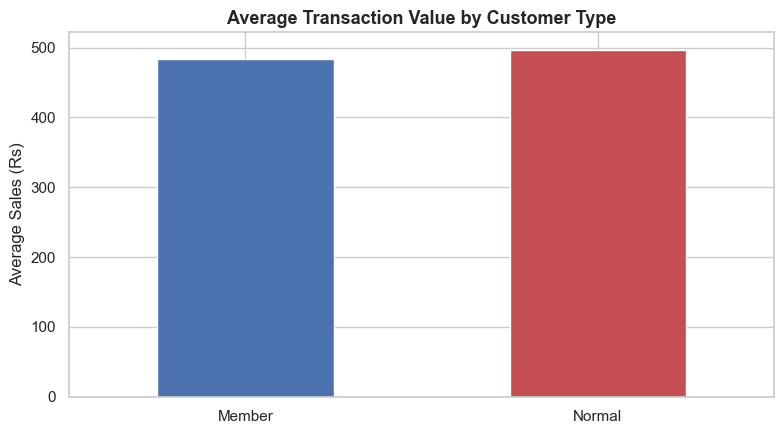

In [24]:
# Calculate average sales by customer type
cust_avg = df.groupby("Customer Type")["Sales"].mean()
print(cust_avg.round(2))

# Compare member vs normal spending
member, normal = cust_avg["Member"], cust_avg["Normal"]
ans = "Yes" if member > normal else "No"
print(f"\n{ans}. Average Member transaction: Rs {member:,.2f} vs Normal: Rs {normal:,.2f}")

# Plot average sales by customer type
cust_avg.plot(kind="bar", color=["#4C72B0", "#C44E52"], rot=0, title="Average Transaction Value by Customer Type")
plt.ylabel("Average Sales (Rs)")
plt.xlabel("")
plt.tight_layout()
plt.show()

#### Q6. What is the average customer rating?

The average customer rating was 3.99 out of 5

Branch
A    3.84
B    3.98
C    4.05
D    4.09
Name: Rating, dtype: float64


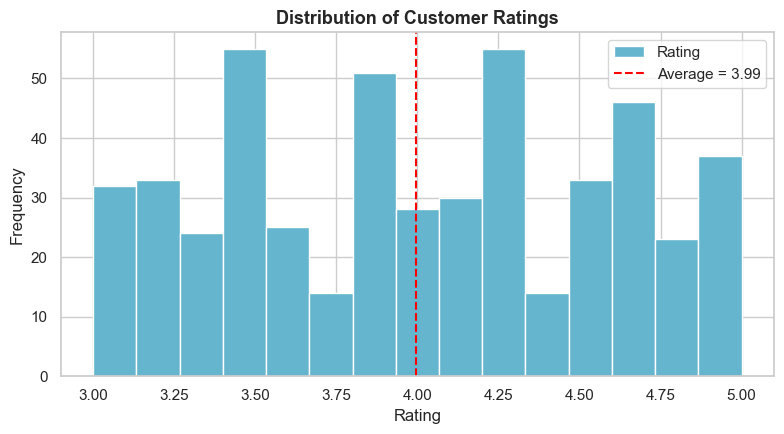

In [25]:
# Calculate and print average ratings
avg_rating = df["Rating"].mean()
print(f"The average customer rating was {avg_rating:.2f} out of 5\n")
print(df.groupby("Branch")["Rating"].mean().round(2))

# Plot rating distribution with average line
ax = df["Rating"].plot(kind="hist", bins=15, color="#64B5CD", edgecolor="white", title="Distribution of Customer Ratings")
ax.axvline(avg_rating, color="red", linestyle="--", label=f"Average = {avg_rating:.2f}")
ax.set_xlabel("Rating")
ax.legend()
plt.tight_layout()
plt.show()

#### Summary of Results

In [26]:
# Compile key findings into a summary table
summary = pd.DataFrame({
    "Question": [
        "Highest selling product",
        "Best performing branch",
        "Top selling category",
        "Most popular payment method",
        "Avg. spend: Member vs Normal",
        "Average customer rating",
    ],
    "Answer": [
        f"{product_sales.index[0]} (Rs {product_sales.iloc[0]:,.2f})",
        f"Branch {best['Branch']} - {best['City']} (Rs {best['Sales']:,.2f})",
        f"{category_sales.index[0]} (Rs {category_sales.iloc[0]:,.2f})",
        f"{payment_counts.index[0]} ({payment_counts.iloc[0]} transactions)",
        f"Member Rs {member:,.2f} vs Normal Rs {normal:,.2f}",
        f"{avg_rating:.2f} / 5",
    ]
})

summary

,Question,Answer
0,Highest selling product,"Cheese (Rs 27,906.30)"
1,Best performing branch,"Branch C - Mumbai (Rs 72,469.45)"
2,Top selling category,"Beverages (Rs 56,108.24)"
3,Most popular payment method,UPI (127 transactions)
4,Avg. spend: Member vs Normal,Member Rs 483.14 vs Normal Rs 497.07
5,Average customer rating,3.99 / 5


## 4. Live Analysis (Results)

| Question | Finding |
|---|---|
| Which product generates the highest sales? | **Cheese** generated the highest sales: ₹27,906.30. |
| Which branch performs best? | **Branch C (Mumbai)** performed best with sales of ₹72,469.45. |
| Which category sells the most? | **Beverages** had the highest sales with ₹56,108.24. |
| What is the most popular payment method? | **UPI** was the most used payment method with 127 transactions. |
| Do Members spend more than Normal customers? | **No.** The average Member transaction was ₹483.14, while Normal customers averaged ₹497.07. |
| What is the average customer rating? | The average customer rating was **3.99 out of 5**. |

## 5. Business Decisions

- Keep **more stock** of high-selling products and categories.
- Study the reasons for **Branch C's strong performance** and apply them to other branches.
- Continue **supporting UPI** payments.
- Improve **customer service** to increase ratings.
- Use customer spending data to plan **membership offers**.

### Step 6: Conclusion & Business Recommendations

Based on our analysis of the supermarket sales data, here are a few quick takeaways for management:

* **Branch Performance:** Review sales distribution across branches to ensure inventory and staff are allocated efficiently to top-performing locations.
* **Product Strategy:** Keep high-revving product lines well-stocked to avoid missed sales opportunities.
* **Next Steps:** Further analysis could look into customer ratings vs. payment methods to optimize the checkout experience.